# Lesson192 · Open FM reproduction: setup & data

**Mirror scope:** setup/data admission for a named RDBLearn published result. The selected full search is blocked by an executed source-preprocessing diagnostic. Default execution authenticates all13,779query records, replays the complete admission audit, and executes the original categorical encoder. It does not fit a backend or pretrain a model.

Python3.12 with pandas, NumPy and scikit-learn. These are standard Colab scientific packages; actual liveColab was NOT_CHECKED. All data, source and figures needed by this notebook are embedded. No network or repository checkout is required. Full original preprocessor execution requires the separately supplied pinned CLI environment.

PROVIDED cells expose the mechanism. Three TODO functions drive the real audit. CHECK cells reject wrong contracts. EXIT requires your written interpretation.

<!-- course-portable:start -->
### Follow the computation

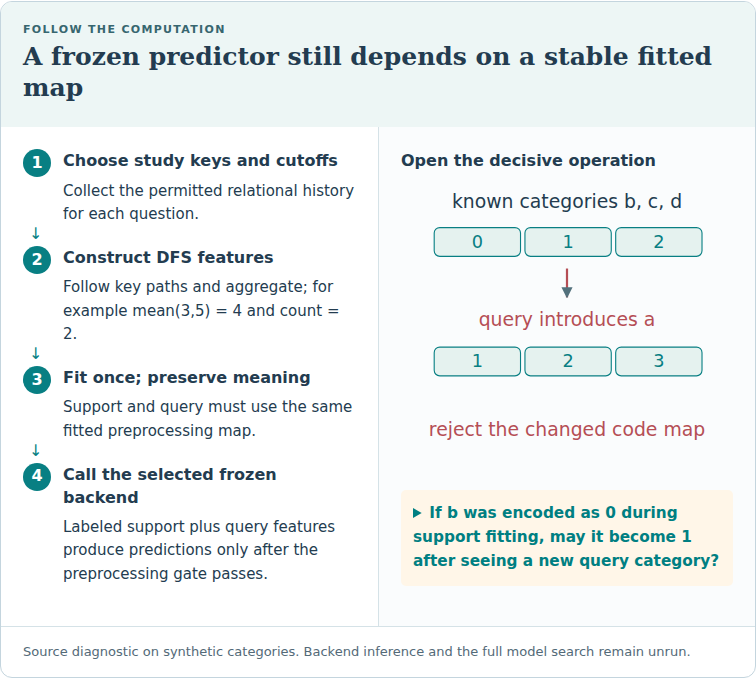

Source diagnostic on synthetic categories. Backend inference and the full model search remain unrun.

**Trace question:** If b was encoded as 0 during support fitting, may it become 1 after seeing a new query category?

**Trace answer:** No. That changes the meaning of an existing coordinate/code. The measured instability blocks backend admission here.
<!-- course-portable:end -->

In [1]:
# @colab-bootstrap
from pathlib import Path
import ast,base64,csv,hashlib,io,json,math,zipfile
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.preprocessing import LabelEncoder
print("L192: audit + original encoder replay; backend inference NOT_RUN")

L192: audit + original encoder replay; backend inference NOT_RUN


## The win: know what you are about to reproduce

A reproducible score begins with a reproducible **input to the model**. Today you will trace one open relational prediction pipeline, authenticate its task rows, and decide whether its source can safely enter a full validation search.

Your tangible deliverable is a **reproduction admission record**: the named target, fixed inputs, complete search schedule, verified invariants, and an evidence-based decision to run or stop. This serves the mission: a thesis about relational models needs comparisons whose inputs retain the same meaning.

**Bridge.** [Lesson 178](https://avistian.github.io/relational/lessons/0178-fair-model-comparison.html) showed that matched support sizes do not guarantee matched information. [Lesson 190](https://avistian.github.io/relational/lessons/0190-research-gap-checkpoint.html) separated research ideas from established evidence. [Lesson 191](https://avistian.github.io/relational/lessons/0191-kumorfm2-sota-tracking.html) audited published commercial-versus-open comparisons. Here we inspect the inputs for a selected open-model reproduction. [Lesson 193](https://avistian.github.io/relational/lessons/0193-open-fm-full-task-set.html) extends its contract to all reported tasks; the source gate found here must be resolved before either model search can run.

<div class="evidence"><strong>Author status:</strong> setup/audit package prepared. Selected model reproduction: <code>INCOMPLETE_SOURCE_PREPROCESSING_GATE</code>. Model evaluations: 0. New cloud/API spend: $0. Learner: <code>PENDING_WRITTEN_DEFENSE</code>.</div>



## 1 · Choose a result, not a model name

**Named experiment.** RDBLearn on RelBench `rel-trial/study-outcome`, targeting **0.7167 AUROC** in the toolkit paper’s Table 1. Its Table 4 names depth 4 with TabPFN-v2 as the selected configuration. We attempt the complete selected-task search instead of assuming that reported winner will win again. Read [the primary paper’s §5 and Appendix A](https://arxiv.org/html/2602.18495v1#S5).

**AUROC** is the probability that a randomly drawn positive example receives a higher score than a randomly drawn negative example, with half credit for a tie. It ranges from 0 to 1. The positive label here is achievement of a primary outcome as defined by the released task SQL. AUC is not accuracy at a chosen decision threshold.

**RDBLearn** combines deterministic relational features with a pretrained tabular predictor. **Deterministic** means the aggregation has no learned weights. **In-context learning**, or ICL, means the predictor conditions on labeled support examples rather than fitting new neural weights for this task. Setting up support is still commonly called `fit` in the software API.

> **Scope check.** “Best open” is the curriculum’s selection goal, not a global ranking certified here. RDBLearn is an open FM-based pipeline; it does not pretrain a new relational foundation model. Source availability, checkpoint access, inference reproduction and reproducing pretraining are different claims.



## 2 · Model architecture: database → features → frozen predictor

<figure class="route-figure">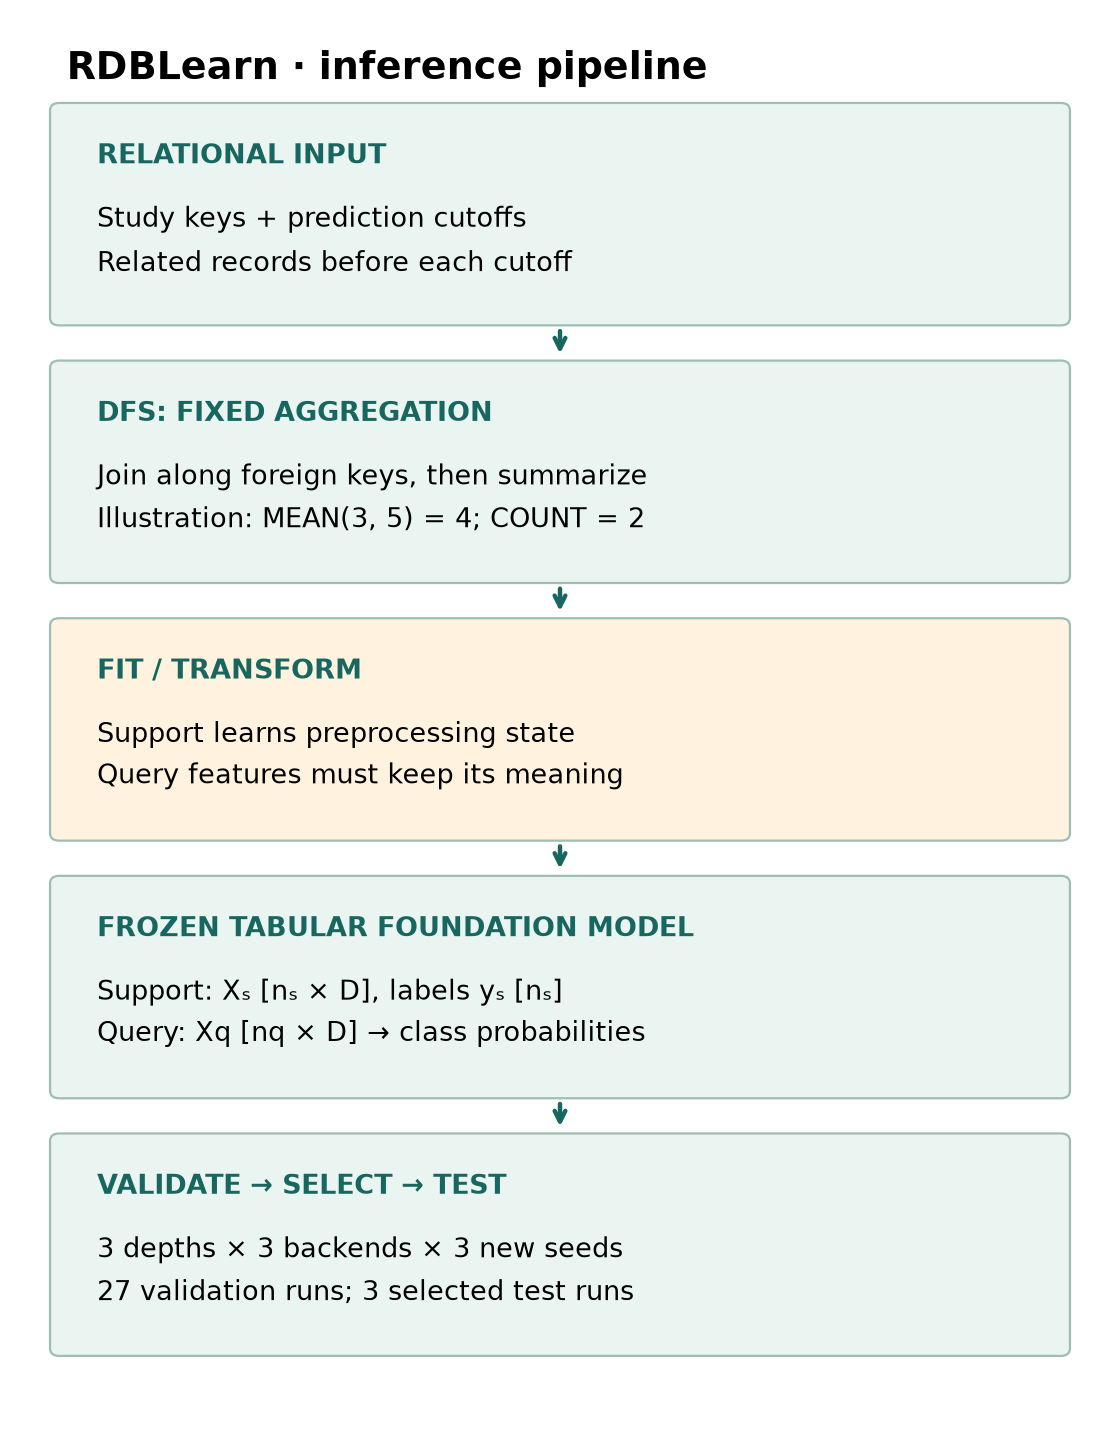<figcaption>RDBLearn’s complete inference route. The mean/count example is illustrative; backend inference and the full search remain unrun. nₛ and nq count support/query rows; D counts features.</figcaption></figure>

**Input.** A study key identifies the entity. A cutoff identifies the moment from which we make the prediction. Other tables connect through **foreign keys**, columns that refer to rows in another table.

**Relational featurization.** Deep Feature Synthesis (DFS) follows these links and applies summaries such as count, mean and maximum. Depth limits how many feature-building stages can compose. A greater depth can make a wider feature table and cost much more to materialize. In the diagram’s illustrative numeric example, two historical values 3 and 5 yield mean 4 and count 2. Those are explanatory values, not clinical data.

**Preprocessing.** Fit the transformations using support data, then apply compatible transformations to validation and test queries. Categorical values become numeric codes. Missing-value handling and feature generation follow the released pipeline. We inspect the actual implementation instead of assuming that its name guarantees imputation or normalization behavior.

**Frozen predictor.** Let `n_s` be the number of support rows, `n_q` the number of query rows, and `D` the number of materialized features. Support features have shape `[n_s, D]`; support labels have shape `[n_s]`; query features have shape `[n_q, D]`. The selected backend produces one class probability per query. TabPFN-v2, TabPFN-v2.5 and LimiX are distinct checkpoint-backed predictors in the paper’s search.

**Where the work is visible.** The notebook contains the original encoder and the complete released estimator/preprocessor source. The estimator shows target-history insertion, downsampling, DFS, preprocessing and backend calls. The underlying frozen tabular networks are not newly implemented or pretrained here. This setup-and-data lesson audits the interface that supplies their inputs. [Pinned estimator](https://github.com/HKUSHXLab/rdblearn/blob/b5b03ebf8091547285a6e06cba53d2d1a40cb171/rdblearn/estimator.py).



## 3 · Authenticate the task, then audit the clock

**Released data.** We downloaded the original task archive and checked SHA256 against the released registry. SHA256 is a content fingerprint: the same bytes produce the same fingerprint. We then compared every extracted task row with the portable audit packet.

| Split | Complete rows | Positive labels |
|---|---:|---:|
| train | 11,994 | 7,647 |
| val | 960 | 561 |
| test | 825 | 483 |


There are **13,779 complete query keys**, with no duplicate `(study, cutoff)` pair. In this particular task, each entity also occurs only once across the supplied rows; that fact does not make entity-only keys safe for other relational tasks. The learner checks deliberately include a repeated entity at two times.

**What the target means.** The released SQL keeps eligible primary-outcome analyses in `(cutoff, cutoff + 365 days]`, subject to its p-value and modifier filters, and labels a study positive when the minimum qualifying p-value is at most 0.05. Eligibility itself depends on having a qualifying future analysis. This is a benchmark cohort, not a claim about prospective prediction for every clinical study. [Released task definition](https://avistian.github.io/relational/labs/sources/l192/trial-task.py).

**Two clocks.** The timestamp of a historical prediction is not the availability time of its eventual label. Our conservative policy admits that label only once its 365-day window has ended. This is a declared audit policy, not a recovered record of when clinical results were published.

<figure class="route-figure">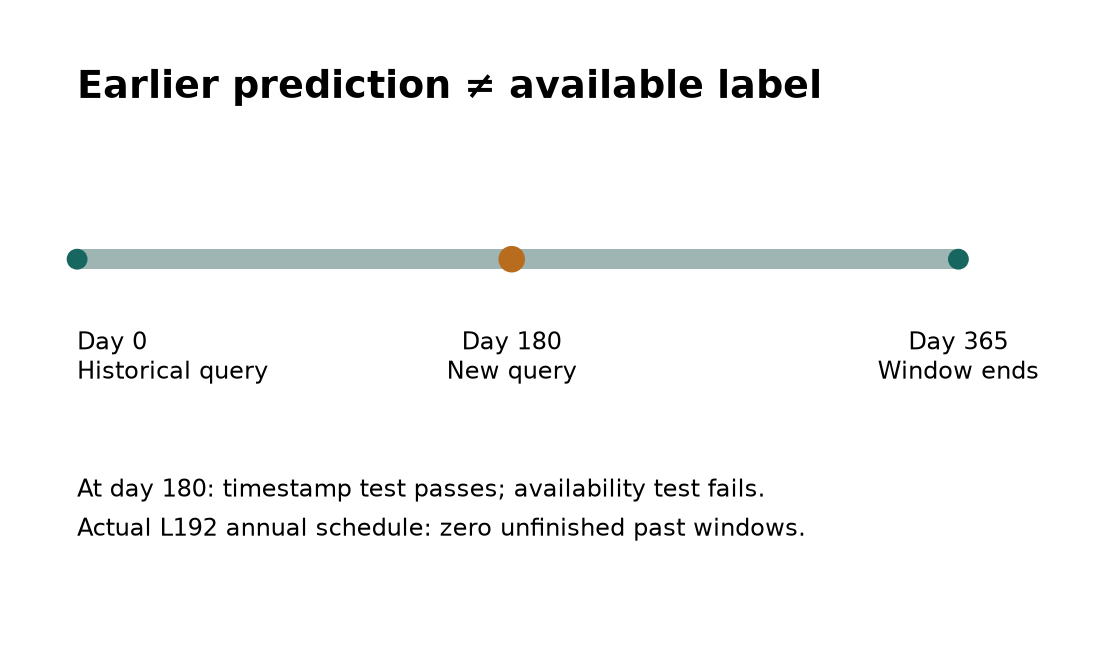<figcaption>Synthetic day-180 counterexample to using prediction time as label availability. The actual official annual schedule has zero unfinished past training windows under the declared window-end policy.</figcaption></figure>

Try the clock example: at day180 the historical prediction is earlier but its label window is unfinished. At day365 both conditions pass.

**Worked example.** A historical prediction occurs on day 0 and its label window ends on day 365. At day 180, `0 < 180` passes the event-time check, but `365 ≤ 180` fails the availability check. At day 365, the conservative availability check passes. This synthetic example explains the distinction.

**Actual task result.** Across every distinct official cutoff, there are **zero earlier training rows whose 365-day windows remain unfinished**. The annual schedule clears this narrow check. We therefore do not call target-history timing a demonstrated failure on this task.

> **Scope check.** We have authenticated all released task rows and audited their schedule. We have not reconstructed labels from the full raw database in L192, materialized the complete relational feature set, or established the historical availability of every raw field. A zero count in the schedule audit is not a complete leakage audit.



## 4 · The source gate: preserve feature meaning

Predict before continuing: after inserting a before b,c,d in sorted order, does b retain code0? Record your answer. The measured answer below is1.

**In plain terms.** If the support set says that category `b` means code 0, a later query containing `b` must use that same meaning. Updating a category dictionary can be valid only if the predictor and all stored support representations remain consistent.

**Worked example.** Fit the released encoder on `b,c,d`, repeated across 12 rows. It sorts the categories and assigns `b→0`, `c→1`, `d→2`. Transform the same three known categories and save their codes. Then transform a new query containing `a`. The implementation inserts `a` into the dictionary and sorts it again. Transforming the original three categories now yields `b→1`, `c→2`, `d→3`.

<figure class="route-figure">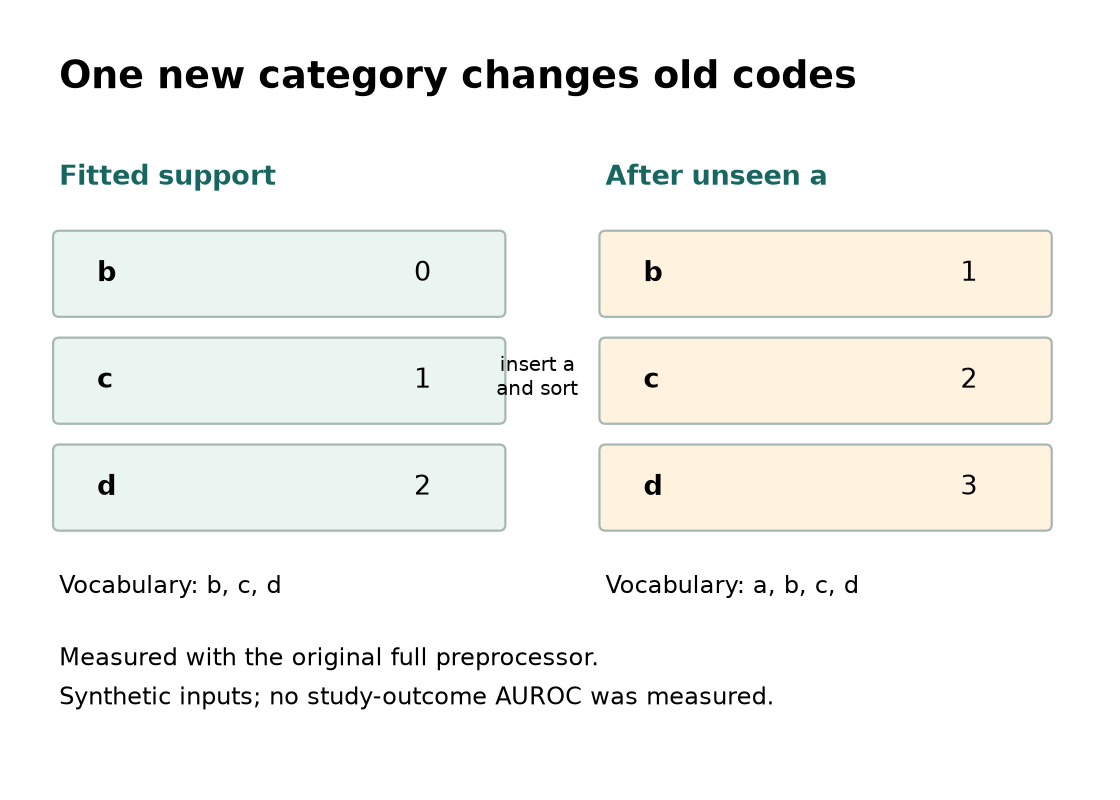<figcaption>Measured original-preprocessor intervention on synthetic categories: support codes0,1,2; after unseen a, known query codes1,2,3. Numeric control unchanged. No model score was measured.</figcaption></figure>

The source failure is a change in **meaning**, not merely a different numeric scale. The stored support matrix was already created using the previous codes. A later transformation does not go back and recode that matrix.

Intervene mentally: inserting z instead of a leaves b,c,d at0,1,2. An illustrative frozen vocabulary preserves known codes for either input; that repair is not a benchmark result.

**Measured evidence.** We executed the complete original `TabularPreprocessor`, including AutoGluon feature generation, on those synthetic inputs. All three known-category codes changed; the numeric control column stayed unchanged. A fresh encoder gave code 0 for `b` alone and code 1 for the same `b` when its batch also contained `a`. A separate original-encoder execution checked 100 generated vocabularies. [Recorded intervention](https://avistian.github.io/relational/labs/evidence/l192/packet/preprocessing.json) · [Independent verification](https://avistian.github.io/relational/labs/_verify_l192_results.json).

**The causal contrast.** Support examples, known query values and numeric values are fixed. The intervention is transforming the unseen category. The measured outcome is the known query representation, not model accuracy. The widget’s frozen-vocabulary option illustrates a possible repair contract; no repaired RDBLearn benchmark was run.

> **Scope check.** This is an executed source-level counterexample on synthetic categories. It does not establish how often the selected task produces such categories, the size or direction of an AUROC effect, or that the authors’ historical run used this exact code. We stop because the released candidate pipeline fails a required input-consistency invariant.



## 5 · Full reproduction includes the search

A **configuration** is a fixed combination of feature depth and backend. For each new repeatability seed, the planned grid has nine candidates: three depths `{2,3,4}` crossed with three backends. Three declared seeds `{0,1,2}` produce **27 validation evaluations**. Each seed selects one winner by maximum validation AUROC; the frozen listing order breaks exact ties. Only those three winners would receive complete test evaluation.

The fit limit stays at the paper’s 10,000 support rows. When necessary, uniform downsampling follows the release. The source stores full target history before downsampling, so “10,000 support rows” must not be read as “only 10,000 accessible labels.” The paper’s historical seeds, exact aggregation and historical checkpoint receipts remain unresolved. Our new seed schedule is an explicit repeatability extension.

**Worked selection example — authored, not measured.** Candidate A has validation AUC 0.62 and B has 0.71. Select B without reading either test score. If one candidate has no validation result, report an incomplete search; silently choosing among the survivors changes the experiment. The notebook rejects missing candidates, duplicated candidates, nonfinite scores and test-labelled selection records.

**Cost gate.** The approved cap is **US$10 total**, including preparation, every seed, retries and verification. Planned stop: **$8**, with **$2 reserved**. A model pilot must support a forecast for the complete remaining search before larger dispatch. There was no admitted model pilot here, so the full-run cost remains **unestablished**, not “under $10.” Actual new cloud/API spend is **$0**. A separate 3,600-second local execution safety limit accounts for setup failures, diagnostics and delivery checks.

Review source/checkpoint/data identity, invariant checks, complete query keys, availability, validation-only selection and full cost. A checked list does not reverse the source failure.



## 6 · Evidence ledger and continuation

| Evidence lane | Actual result | Boundary |
|---|---|---|
| Released task archive | Authenticated; 13,779 complete keys | Raw-label reconstruction not rerun |
| Annual window-end schedule | Zero unfinished past training windows | Not a full feature-availability audit |
| Original full preprocessor | Known codes 0,1,2 → 1,2,3 after unseen a | Synthetic source counterexample |
| Independent original encoder | 100 generated cases confirm shifts | Task AUROC impact unmeasured |
| Complete selected-task search | 27 validation + 3 selected tests planned; 0 run | INCOMPLETE_SOURCE_PREPROCESSING_GATE |
| Published AUROC target | 0.7167 cited; measured score absent | No match or superiority claim |
| Pretraining / whole-paper benchmark | NOT_RUN | Outside this selected-task evidence |


A passing lesson audit and a completed model reproduction are different outcomes. The audit reproduces the source failure; the intended 0.7167 model result remains unrun. “Incomplete” is an informative research result when it names the precise gate and preserves the next decision.

**Continuation requires** either an authentic historical configuration that resolves the preprocessing discrepancy or an explicitly declared repair. Then freeze checkpoint hashes and a compatible complete environment, audit full features and availability, measure the complete search cost, and execute the unchanged admitted grid. A repair begins a new comparison; it cannot retroactively establish the old result. No backend, seed count or dataset size was silently substituted.



## Lab · build the admission record

[Student notebook](https://avistian.github.io/relational/labs/0192-open-fm-setup-data.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/solutions/0192-open-fm-setup-data.ipynb) · [Readable lab](https://avistian.github.io/relational/labs/html/0192-open-fm-setup-data.html) · [Reference card](https://avistian.github.io/relational/reference/open-fm-setup-data.html) · [Complete reproduction contract](https://avistian.github.io/relational/labs/l192-reproduction.md).

You implement three functions: complete query indexing, label-availability admission and validation-only selection. They feed the complete packet audit. You also execute the unmodified released categorical encoder and compare it with the saved full-preprocessor evidence. Everything needed for the default notebook is embedded; it performs no cloud dispatch or backend model inference.

**EXIT.** Return the audit report and a written defense: which checks passed, why the source gate stopped inference, why the counterexample does not prove the paper’s number wrong, and which new evidence would admit continuation. Executing the author solution does not establish your mastery.

Write a defense of the source gate, actual task checks, remaining uncertainty and next admissible experiment. Do not claim historical AUROC harm from this synthetic failure.

Tomorrow, reconstruct the two clocks from memory. In one week, explain why preprocessing must remain consistent after `fit`, then design a fresh counterexample with a different category order. Ask the agent follow-up questions or paste your EXIT defense for feedback.


## PROVIDED · Authenticate the embedded evidence

The archive hash pins every byte. The visible audit independently checks each member against the input manifest. Hash agreement proves input identity, not scientific validity. The complete original preprocessor observations are author evidence; your next cells replay the primitive separately.

In [2]:
PACKET='...'
raw=base64.b64decode(PACKET)
assert hashlib.sha256(raw).hexdigest()=='8d32449325e81ee56c93c129464c9b921321b5d7e9b0800abb815fa9f7b12d9b'
packet=Path('l192-packet');packet.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(raw)) as z:
    for name in z.namelist():
        assert not Path(name).is_absolute() and '..' not in Path(name).parts
    z.extractall(packet)
manifest={'files': {'after.csv': '30065959c7b3f2146106d2aa448425e00c7e18b91d6068d8d2d9f9c8c070ca8f', 'before.csv': '07d4f0697a715631b66f782cb6495927393551c4c0a523e62d0c27547b381300', 'config.py': '3e964deae390ee1634732906350d0c1cce5f062e68a73e4693ad045132694f0f', 'constants.py': '26add045030ba0af141b0ecf2cc2b573402d3a64c2c1163f6c2e40b5498340fc', 'estimator.py': '44df25e6b43f3bfb86f5e2aa9ec23544aedf565c7e9e35706918365c4e71c23e', 'fit-matrix.csv': 'fc0cfddefa91364d7a328fa91e28b0d275dcf897c58fd41b05e4d0899c4bac5b', 'known.csv': '909025c3e1d92867a1d6f313b152ee5dc3f3da72d7ca98f4917b3a9e862f9432', 'preprocessing.json': '4519bcafc5c8b5cbc6762bb3612bb49d91a6676a2425415adac5655f9450a2b3', 'preprocessing.py': '87fa6f9fe7d441fbcd5fd4e6119fd97b35a13c6d2ad6dd3e4195beb9c3229371', 'protocol.json': 'e813890981208741d022ffe7ea5baf8587fd465c365e0b494bd575103e5cb870', 'queries.json': 'd19c6154a047b1ebb79b18ea2b319bb5933fa3d88ff35e2dd301742009a095b3', 'task-stats.json': 'c7cb1e5af874429992be581fe4e627d4a2cfc0f0af0aa93d5c900b1087be35c4', 'train.csv': '005fc849a6f4360061ff67b3c5bd667e00a6003f39891ed6900f585a34996224', 'unseen-input.csv': 'd2450425d59b703829621d668e5285121a2f33b00b1ebe54cfe9fe88aea742e1'}}

## TODO · keyed_rows

**Goal.** Index rows by (entity,cutoff). Require integer entity/day/binary label values (booleans are not valid integers here), reject duplicate full keys, preserve repeated entities at different cutoffs. Return a dictionary from key to original row.

**Why.** This contract contributes to the complete admission record, so a locally convenient shortcut cannot silently change the experiment.

In [3]:
def keyed_rows(rows):
    """Index integer entity/day records, rejecting duplicate complete query keys."""
    result={}
    for row in rows:
        if any(type(row.get(k)) is not int for k in ['entity','cutoff','label']):
            raise ValueError('Entity, cutoff day and binary label must be integers')
        if row['label'] not in [0,1]:raise ValueError('Binary label required')
        key=(row['entity'],row['cutoff'])
        if key in result:raise ValueError('Duplicate complete query key')
        result[key]=row
    return result

### CHECK · immediate feedback

In [4]:
toy=[dict(entity=7,cutoff=10,label=1),dict(entity=7,cutoff=20,label=0)]
assert len(keyed_rows(toy))==2
print('Two times for one entity retained')

Two times for one entity retained


## TODO · available_history

**Goal.** Accept integer query day and history rows with integer available_at no earlier than their own cutoff. Validate the complete keys using your keyed_rows. Return original rows in order only when their prediction cutoff is earlier and their label is available by the query day. Reject missing availability instead of guessing.

**Why.** This contract contributes to the complete admission record, so a locally convenient shortcut cannot silently change the experiment.

In [5]:
def available_history(history, query_cutoff):
    """Retain past query labels whose declared availability is no later than now."""
    if type(query_cutoff) is not int:raise ValueError('Integer cutoff day required')
    keyed_rows(history)
    for row in history:
        if type(row.get('available_at')) is not int or row['available_at']<row['cutoff']:
            raise ValueError('Missing or invalid label availability')
    return [r for r in history if r['cutoff']<query_cutoff and r['available_at']<=query_cutoff]

### CHECK · immediate feedback

In [6]:
history=[dict(entity=7,cutoff=0,label=1,available_at=365)]
assert available_history(history,180)==[]
assert available_history(history,365)==history
print('Prediction and availability clocks checked')

Prediction and availability clocks checked


## TODO · select_candidate

**Goal.** Accept the frozen candidate order and a complete set of validation records. Require finite AUROC in[0,1], unique known IDs and exactly the expected grid. Reject test records, duplicates, unknowns and incomplete grids. Return the maximum-validation candidate; frozen order breaks ties.

**Why.** This contract contributes to the complete admission record, so a locally convenient shortcut cannot silently change the experiment.

In [7]:
def select_candidate(records, expected):
    """Only a complete validation grid may select; ties follow the frozen order."""
    if not expected or len(set(expected))!=len(expected):raise ValueError('Invalid candidate grid')
    by_id={}
    for row in records:
        score=row.get('auc')
        if row.get('split')!='val' or type(score) not in [float,int] or not math.isfinite(score) or not 0<=score<=1:
            raise ValueError('Finite validation AUROC in [0,1] required')
        if row.get('id') not in expected or row['id'] in by_id:raise ValueError('Unknown or duplicate candidate')
        by_id[row['id']]=score
    if set(by_id)!=set(expected):raise ValueError('Incomplete validation search')
    return max(expected,key=lambda name:by_id[name])

### CHECK · immediate feedback

In [8]:
example=[dict(id='a',split='val',auc=.62),dict(id='b',split='val',auc=.71)]
assert select_candidate(example,['a','b'])=='b'
print('Authored selection example: b; no model result')

Authored selection example: b; no model result


## CHECK · malformed and incomplete experiments
These tests exercise all three live functions, including duplicate keys, missing availability, unknown candidates, ties and test-score contamination.

In [9]:
def checks(keyed_rows,available_history,select_candidate):
    def reject(fn,*args):
        try:fn(*args)
        except (ValueError,TypeError):return
        raise AssertionError('Invalid input was accepted')
    rows=[{'entity':4,'cutoff':10,'label':1},{'entity':4,'cutoff':20,'label':0}]
    assert len(keyed_rows(rows))==2,'Entity alone loses repeated queries'
    reject(keyed_rows,rows+[rows[0]])
    reject(keyed_rows,[{'entity':True,'cutoff':10,'label':1}])
    reject(keyed_rows,[{'entity':4,'cutoff':float('nan'),'label':1}])
    h=[{'entity':4,'cutoff':1,'available_at':8,'label':1},
       {'entity':4,'cutoff':5,'available_at':15,'label':0},
       {'entity':4,'cutoff':10,'available_at':10,'label':1}]
    assert available_history(h,10)==[h[0]],'Require event before query and label available by query'
    assert available_history(h,15)==h,'Availability equality is admitted; query time must be later'
    reject(available_history,[dict(h[0],available_at=None)],10)
    reject(available_history,[dict(h[0],available_at=0)],10)
    expected=['d2-v2','d3-v2'];r=[dict(id=expected[0],split='val',auc=.6),dict(id=expected[1],split='val',auc=.7)]
    assert select_candidate(r,expected)=='d3-v2'
    assert select_candidate(list(reversed([dict(x,auc=.7) for x in r])),expected)=='d2-v2','Frozen order breaks ties'
    reject(select_candidate,r[:1],expected)
    reject(select_candidate,r+[r[0]],expected)
    reject(select_candidate,[dict(r[0],split='test'),r[1]],expected)
    for bad in [True,float('nan'),float('inf'),-.1,1.1]:reject(select_candidate,[dict(r[0],auc=bad),r[1]],expected)
    return {'status':'PASS','contracts':['complete query identity','label availability','complete validation-only selection']}

In [10]:
print(checks(keyed_rows,available_history,select_candidate))

{'status': 'PASS', 'contracts': ['complete query identity', 'label availability', 'complete validation-only selection']}


## PROVIDED · Original released categorical encoder

This class is unmodified source from the pinned RDBLearn release. Follow fit, unseen detection, dictionary expansion and sorting. It is the same class called by the released full preprocessor, whose complete source is readable after EXIT. We execute the class with real pandas/NumPy/scikit-learn; there is no emulated LabelEncoder.

In [11]:
class SafeLabelEncoderTransformer(BaseEstimator, TransformerMixin):
    """
    Wraps standard LabelEncoder logic but handles unseen labels dynamically by expanding classes,
    matching original implementation behavior.
    """
    def __init__(self):
        self.label_encoders_ = {}
        self.cat_columns_ = []

    def fit(self, X: pd.DataFrame, y=None):
        # Identify object/category columns
        self.cat_columns_ = X.select_dtypes(include=['object', 'category']).columns.tolist()
        for col in self.cat_columns_:
            le = LabelEncoder()
            # Convert to string to handle mixed types/NaNs consistently
            le.fit(X[col].astype(str))
            self.label_encoders_[col] = le
        return self

    def transform(self, X: pd.DataFrame):
        X = X.copy()
        for col in self.cat_columns_:
            if col in X.columns:
                le = self.label_encoders_[col]
                vals = X[col].astype(str)
                
                # Check for unseen labels and expand if necessary
                unseen_mask = ~vals.isin(le.classes_)
                if unseen_mask.any():
                    # Extend classes with new unseen labels
                    new_classes = vals[unseen_mask].unique()
                    le.classes_ = np.concatenate([le.classes_, new_classes])
                    # Re-sort if strictly necessary for LabelEncoder, but usually unnecessary for just transform mapping
                    le.classes_ = np.sort(le.classes_)
                
                X[col] = le.transform(vals)
        return X

### Predict, then intervene
Predict the known-category codes before and after transforming a new category. The stored support matrix remains fixed. The source counterexample is synthetic, while the task audit below uses real released task rows.

In [12]:
support=pd.DataFrame({'category':pd.Series(['b','c','d']*4,dtype='object')})
known=pd.DataFrame({'category':pd.Series(['b','c','d'],dtype='object')})
enc=SafeLabelEncoderTransformer().fit(support)
before=enc.transform(known).category.tolist()
enc.transform(pd.DataFrame({'category':pd.Series(['a'],dtype='object')}))
after=enc.transform(known).category.tolist()
assert before==[0,1,2] and after==[1,2,3]
observed=json.loads((packet/'preprocessing.json').read_text())
assert before==observed['before']['category'] and after==observed['after']['category']
print('Original encoder:',before,'→',after)
print('Full-preprocessor author evidence matches this primitive; no model AUROC measured')

Original encoder: [0, 1, 2] → [1, 2, 3]
Full-preprocessor author evidence matches this primitive; no model AUROC measured


## PROVIDED · Complete visible admission audit

The canonical function below uses your three functions. It audits every query key and every distinct cutoff, verifies the recorded transformation against independent sorted-set arithmetic, and separates planned evaluation counts from measured model runs.

In [13]:
def audit(packet,manifest,keyed_rows,available_history,select_candidate):
    packet=Path(packet)
    for name,digest in manifest['files'].items():
        if hashlib.sha256((packet/name).read_bytes()).hexdigest()!=digest:raise ValueError('Corrupt packet: '+name)
    rows=json.loads((packet/'queries.json').read_text());protocol=json.loads((packet/'protocol.json').read_text())
    by_split={s:[r for r in rows if r['split']==s] for s in ['train','val','test']}
    indexed={s:keyed_rows(rs) for s,rs in by_split.items()}
    if sum(map(len,indexed.values()))!=len(rows):raise ValueError('Unknown split')
    all_keys=keyed_rows(rows)
    stats={s:dict(rows=len(rs),unique_entities=len({r['entity'] for r in rs}),positives=sum(r['label'] for r in rs)) for s,rs in by_split.items()}
    times=sorted({r['cutoff'] for r in rows});clock=[]
    for t in times:
        past=[r for r in by_split['train'] if r['cutoff']<t]
        admitted=available_history(by_split['train'],t)
        clock.append(dict(cutoff=t,past_train_rows=len(past),available_train_rows=len(admitted),unavailable_past_rows=len(past)-len(admitted)))
    # This schedule audit does not materialize full relational features or infer arrival times.
    before=list(csv.DictReader(io.StringIO((packet/'before.csv').read_text())))
    after=list(csv.DictReader(io.StringIO((packet/'after.csv').read_text())))
    observed=json.loads((packet/'preprocessing.json').read_text())
    old=[int(x['category']) for x in before];new=[int(x['category']) for x in after]
    original_map={c:i for i,c in enumerate(sorted(set(observed['train_categories'])))}
    expanded_map={c:i for i,c in enumerate(sorted(set(observed['train_categories']+observed['unseen_categories'])))}
    expected_before=[original_map[c] for c in observed['known_categories']]
    expected_after=[expanded_map[c] for c in observed['known_categories']]
    if old!=expected_before or new!=expected_after:raise ValueError('Independent mapping audit failed')
    changed=sum(a!=b for a,b in zip(old,new));assert changed==3
    if any(a['number']!=b['number'] for a,b in zip(before,after)):raise ValueError('Numeric control changed')
    candidates=[f'd{d}-{b}' for d in protocol['depths'] for b in protocol['backends']]
    # Authored selection exercise; these values are not model results.
    toy=[dict(id='example-a',split='val',auc=.62),dict(id='example-b',split='val',auc=.71)]
    toy_winner=select_candidate(toy,['example-a','example-b'])
    assert toy_winner=='example-b'
    return dict(status='INCOMPLETE_SOURCE_PREPROCESSING_GATE',task='rel-trial/study-outcome',paper_target_auc=protocol['target_auc'],measured_auc=None,task_queries=len(all_keys),splits=stats,
                complete_key_collisions=0,clock_audit=clock,unavailable_past_train_rows=sum(r['unavailable_past_rows'] for r in clock),
                availability_scope='Window-end policy only; no raw database reconstruction or historical arrival proof',
                preprocessing=dict(status='FAIL',before=old,after=new,changed_known_codes=changed,numeric_control='UNCHANGED',scope='Synthetic original-source diagnostic; task effect NOT_ESTABLISHED'),
                planned_validation_candidates=len(candidates)*len(protocol['seeds']),planned_test_evaluations=len(protocol['seeds']),executed_model_evaluations=0,forecast='NOT_ESTABLISHED',cloud_usd=0,
                selection_exercise=dict(scope='AUTHORED_NOT_MODEL_SCORES',winner=toy_winner),full_feature_audit='NOT_RUN',fresh_pretraining='NOT_RUN',whole_paper='NOT_RUN',historical_identity='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE')

In [14]:
report=audit(packet,manifest,keyed_rows,available_history,select_candidate)
Path('l192-report.json').write_text(json.dumps(report,indent=2)+'\n')
print(report['status'])
print('Official queries:',report['task_queries'])
print('Unfinished earlier training windows:',report['unavailable_past_train_rows'])
print('Model evaluations:',report['executed_model_evaluations'])
assert report=={'status': 'INCOMPLETE_SOURCE_PREPROCESSING_GATE', 'task': 'rel-trial/study-outcome', 'paper_target_auc': 0.7167, 'measured_auc': None, 'task_queries': 13779, 'splits': {'train': {'rows': 11994, 'unique_entities': 11994, 'positives': 7647}, 'val': {'rows': 960, 'unique_entities': 960, 'positives': 561}, 'test': {'rows': 825, 'unique_entities': 825, 'positives': 483}}, 'complete_key_collisions': 0, 'clock_audit': [{'cutoff': 11327, 'past_train_rows': 0, 'available_train_rows': 0, 'unavailable_past_rows': 0}, {'cutoff': 11692, 'past_train_rows': 2, 'available_train_rows': 2, 'unavailable_past_rows': 0}, {'cutoff': 12057, 'past_train_rows': 4, 'available_train_rows': 4, 'unavailable_past_rows': 0}, {'cutoff': 12422, 'past_train_rows': 11, 'available_train_rows': 11, 'unavailable_past_rows': 0}, {'cutoff': 12787, 'past_train_rows': 44, 'available_train_rows': 44, 'unavailable_past_rows': 0}, {'cutoff': 13152, 'past_train_rows': 81, 'available_train_rows': 81, 'unavailable_past_rows': 0}, {'cutoff': 13517, 'past_train_rows': 170, 'available_train_rows': 170, 'unavailable_past_rows': 0}, {'cutoff': 13882, 'past_train_rows': 374, 'available_train_rows': 374, 'unavailable_past_rows': 0}, {'cutoff': 14247, 'past_train_rows': 1099, 'available_train_rows': 1099, 'unavailable_past_rows': 0}, {'cutoff': 14612, 'past_train_rows': 1931, 'available_train_rows': 1931, 'unavailable_past_rows': 0}, {'cutoff': 14977, 'past_train_rows': 2791, 'available_train_rows': 2791, 'unavailable_past_rows': 0}, {'cutoff': 15342, 'past_train_rows': 3656, 'available_train_rows': 3656, 'unavailable_past_rows': 0}, {'cutoff': 15707, 'past_train_rows': 4543, 'available_train_rows': 4543, 'unavailable_past_rows': 0}, {'cutoff': 16072, 'past_train_rows': 5493, 'available_train_rows': 5493, 'unavailable_past_rows': 0}, {'cutoff': 16437, 'past_train_rows': 6483, 'available_train_rows': 6483, 'unavailable_past_rows': 0}, {'cutoff': 16802, 'past_train_rows': 7527, 'available_train_rows': 7527, 'unavailable_past_rows': 0}, {'cutoff': 17167, 'past_train_rows': 8620, 'available_train_rows': 8620, 'unavailable_past_rows': 0}, {'cutoff': 17532, 'past_train_rows': 9773, 'available_train_rows': 9773, 'unavailable_past_rows': 0}, {'cutoff': 17897, 'past_train_rows': 10901, 'available_train_rows': 10901, 'unavailable_past_rows': 0}, {'cutoff': 18262, 'past_train_rows': 11994, 'available_train_rows': 11994, 'unavailable_past_rows': 0}, {'cutoff': 18628, 'past_train_rows': 11994, 'available_train_rows': 11994, 'unavailable_past_rows': 0}], 'unavailable_past_train_rows': 0, 'availability_scope': 'Window-end policy only; no raw database reconstruction or historical arrival proof', 'preprocessing': {'status': 'FAIL', 'before': [0, 1, 2], 'after': [1, 2, 3], 'changed_known_codes': 3, 'numeric_control': 'UNCHANGED', 'scope': 'Synthetic original-source diagnostic; task effect NOT_ESTABLISHED'}, 'planned_validation_candidates': 27, 'planned_test_evaluations': 3, 'executed_model_evaluations': 0, 'forecast': 'NOT_ESTABLISHED', 'cloud_usd': 0, 'selection_exercise': {'scope': 'AUTHORED_NOT_MODEL_SCORES', 'winner': 'example-b'}, 'full_feature_audit': 'NOT_RUN', 'fresh_pretraining': 'NOT_RUN', 'whole_paper': 'NOT_RUN', 'historical_identity': 'NOT_ESTABLISHED', 'learner': 'PENDING_WRITTEN_DEFENSE'}

INCOMPLETE_SOURCE_PREPROCESSING_GATE
Official queries: 13779
Unfinished earlier training windows: 0
Model evaluations: 0


## EXIT · your admission record

Write a defense of the stopped reproduction. Name the target, the complete search, the failed invariant, the passing task checks and their limits. Explain why changing the encoder would require a new declared protocol. State the evidence and complete cost forecast needed before continuation. Leave author preparation separate from your own mastery.

In [15]:
defense=''  # Write your own reasoning; the solution does not impersonate a learner.
submission=dict(status=report['status'],defense=defense,learner='PENDING_WRITTEN_DEFENSE',model_auc=None)
Path('l192-submission.json').write_text(json.dumps(submission,indent=2)+'\n')
print(submission['learner'])

PENDING_WRITTEN_DEFENSE


## Full reproduction continuation — source-gated

The27validation candidates and3selected tests remain NOT_RUN. The benchmark operator is not admitted or claimed ready: checkpoint identities, full feature checks and full cost remain unresolved. See the distributed `l192-reproduction.md` for tested audit/preflight commands. No RUN flag bypasses the failed gate. This preserves the intended experiment rather than quietly replacing its backend or sample size.

The following complete release source makes the blocked pipeline reviewable. It is displayed, not automatically executed: importing AutoGluon or a model environment is outside this notebook’s default dependency contract.

### Original constants.py · module constants

```python
TABPFN_DEFAULT_CONFIG = {
    "n_estimators": 8,
    "ignore_pretraining_limits": True,  # Allow datasets larger than 10K samples
    "device": "cuda",
    "n_preprocessing_jobs": -1
}
```

### Original constants.py · module constants

```python
RDBLEARN_DEFAULT_CONFIG = {
    "dfs": {
        "max_depth": 2,
        "agg_primitives": ["max", "min", "mean", "count", "mode", "std"],
        "engine": "dfs2sql"
    },
    "max_train_samples": 10000,
    "stratified_sampling": False,
    "predict_batch_size": 5000
}
```

### Original constants.py · module constants

```python
TARGET_HISTORY_TABLE_NAME = "_RDBL_target_history"
```

### Original config.py · imports

```python
from pydantic import BaseModel, Field
from typing import Optional, Union, Dict, Any, List
from dataclasses import dataclass, field
from fastdfs import DFSConfig
```

### Original config.py · TemporalDiffConfig

```python
class TemporalDiffConfig(BaseModel):
    """Configuration for temporal difference feature generation."""
    enabled: bool = True
    # Columns to explicitly exclude from transformation
    exclude_columns: List[str] = Field(default_factory=list)
```

### Original config.py · RDBLearnConfig

```python
class RDBLearnConfig(BaseModel):
    """
    Configuration for RDBLearnEstimator.
    """
    # DFS Configuration (passed to fastdfs)
    # If None, defaults to: {"max_depth": 2, "agg_primitives": ["max", "min", "mean", "count", "mode", "std"], "engine": "dfs2sql"}
    dfs: Optional[DFSConfig] = None
    
    # Preprocessing Configuration (passed to AutoGluon feature generator)
    # If None, defaults to: {"enable_datetime_features": True, "enable_raw_text_features": False, ...}
    ag_config: Optional[Dict[str, Any]] = None
    
    # Sampling Configuration
    max_train_samples: int = 10000
    stratified_sampling: bool = False  # Ignored for RDBLearnRegressor
    
    # Target History Augmentation
    enable_target_augmentation: bool = True
    
    # Prediction Configuration
    predict_batch_size: int = 5000

    # Temporal Difference Configuration (post-DFS transformation)
    temporal_diff: Optional[TemporalDiffConfig] = TemporalDiffConfig()

    class Config:
        arbitrary_types_allowed = True
```

### Original preprocessing.py · imports

```python
from typing import Optional, Dict, Any, List
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from autogluon.features.generators import AutoMLPipelineFeatureGenerator
from loguru import logger
from .config import TemporalDiffConfig
```

### Original preprocessing.py · TypeCastTransformer

```python
class TypeCastTransformer(BaseEstimator, TransformerMixin):
    """
    Transformer to cast boolean and nullable Int64 columns to float32.
    Handles <NA> values by converting them to np.nan.
    """
    def fit(self, X: pd.DataFrame, y=None):
        self.is_fitted_ = True
        return self

    def transform(self, X: pd.DataFrame):
        X = X.copy()
        for col in X.columns:
            # Check for boolean types
            is_bool = pd.api.types.is_bool_dtype(X[col])
            # Check for nullable Int64 (often comes from mixed sources)
            is_nullable_int = str(X[col].dtype) == 'Int64'

            if is_bool or is_nullable_int:
                # astype('float32') handles mapping <NA>/None/False->0/True->1 correctly
                # and converts <NA> to IEEE 754 NaN
                X[col] = X[col].astype('float32')
        return X
```

### Original preprocessing.py · TemporalDiffTransformer

```python
class TemporalDiffTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, config: TemporalDiffConfig, cutoff_time_col: Optional[str] = None):
        self.config = config
        self.cutoff_time_col = cutoff_time_col
        self.timestamp_columns_: List[str] = []

    def _sanitize_column_name(self, col: str) -> str:
        sanitized = col.replace('(', '_').replace(')', '').replace('.', '_')
        while '__' in sanitized:
            sanitized = sanitized.replace('__', '_')
        sanitized = sanitized.strip('_')
        return sanitized

    def fit(self, X: pd.DataFrame, y=None):
        # Find all epochtime columns
        all_epochtime_cols = [
            col for col in X.columns
            if '_epochtime' in col and col not in self.config.exclude_columns
        ]
        
        # Drop epochtime columns containing 'std' — std of timestamps is meaningless.
        self.columns_to_drop_ = [
            col for col in all_epochtime_cols if 'std' in col.lower()
        ]

        # Transform all remaining epochtime columns
        self.timestamp_columns_ = [
            col for col in all_epochtime_cols if col not in self.columns_to_drop_
        ]

        if self.timestamp_columns_:
            logger.info(f"TemporalDiffTransformer: Found {len(self.timestamp_columns_)} timestamp columns for transformation.")
        if self.columns_to_drop_:
            logger.info(f"TemporalDiffTransformer: Will drop {len(self.columns_to_drop_)} epochtime columns containing 'std'.")
        
        return self

    def transform(self, X: pd.DataFrame):
        X = X.copy()
        
        # Drop unwanted epochtime columns first
        if self.columns_to_drop_:
            cols_present = [col for col in self.columns_to_drop_ if col in X.columns]
            if cols_present:
                X = X.drop(columns=cols_present)
        
        if not self.timestamp_columns_:
            return X

        if self.cutoff_time_col is None or self.cutoff_time_col not in X.columns:
            return X

        cutoff_series = X[self.cutoff_time_col]
        cutoff_nano = (cutoff_series.astype('datetime64[ns]') - np.array(0).astype('datetime64[ns]')).astype('int64')

        for col in self.timestamp_columns_:
            if col not in X.columns:
                continue

            timestamp_nano = X[col].values
            time_diff = (cutoff_nano - timestamp_nano).astype('float64')

            sanitized_name = self._sanitize_column_name(col)
            feature_name = f"{sanitized_name}_diff"

            X[feature_name] = time_diff
            X = X.drop(columns=[col])

        logger.info(f"TemporalDiffTransformer: Generated {len(self.timestamp_columns_)} temporal difference features.")
        return X
```

### Original preprocessing.py · AutoGluonTransformer

```python
class AutoGluonTransformer(BaseEstimator, TransformerMixin):
    """
    Scikit-learn wrapper for AutoGluon's AutoMLPipelineFeatureGenerator.
    """
    def __init__(self, ag_config: Optional[Dict[str, Any]] = None):
        self.ag_config = ag_config
        self.feature_generator_ = None
        
        self._default_ag_config = {
            "enable_datetime_features": True,
            "enable_raw_text_features": False,
            "enable_text_special_features": False,
            "enable_text_ngram_features": False,
        }
        if self.ag_config:
            self._default_ag_config.update(self.ag_config)

    def fit(self, X: pd.DataFrame, y=None):
        self.feature_generator_ = AutoMLPipelineFeatureGenerator(**self._default_ag_config)
        # AutoGluon generator fits and needs the data
        self.feature_generator_.fit(X=X)
        return self

    def transform(self, X: pd.DataFrame):
        if self.feature_generator_ is None:
            raise RuntimeError("AutoGluonTransformer not fitted.")
        return self.feature_generator_.transform(X)
```

### Original preprocessing.py · TabularPreprocessor

```python
class TabularPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(
        self, 
        ag_config: Optional[Dict[str, Any]] = None,
        temporal_diff_config: Optional[TemporalDiffConfig] = None,
        cutoff_time: Optional[str] = None
    ):
        self.ag_config = ag_config
        self.temporal_diff_config = temporal_diff_config
        self.cutoff_time = cutoff_time
        self.pipeline = None
        self.is_fitted_ = False

    def fit(self, X: pd.DataFrame, y=None):
        """Fit the preprocessor pipeline on training data."""
        steps = []

        # 1. Type Casting (Must be first to fix legacy types)
        steps.append(('type_cast', TypeCastTransformer()))

        # 2. Temporal Features
        if self.temporal_diff_config and self.temporal_diff_config.enabled:
            # We pass the column name for cutoff time so the transformer can find it in X
            steps.append(('temporal', TemporalDiffTransformer(
                config=self.temporal_diff_config, 
                cutoff_time_col=self.cutoff_time
            )))
        
        # 3. Categorical Encoding
        steps.append(('label_encoder', SafeLabelEncoderTransformer()))

        # 4. AutoGluon Features
        steps.append(('autogluon', AutoGluonTransformer(ag_config=self.ag_config)))

        self.pipeline = Pipeline(steps)
        logger.debug(f"Preprocessor pipeline: {self.pipeline}")

        self.pipeline.fit(X, y)
        self.is_fitted_ = True
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        """Transform features using the fitted pipeline."""
        if self.pipeline is None:
            raise RuntimeError("Preprocessor not fitted.")
        
        return self.pipeline.transform(X)
```

### Original estimator.py · imports

```python
from typing import Optional, Dict, Union, List
import pandas as pd
import numpy as np
from loguru import logger
from sklearn.base import BaseEstimator, ClassifierMixin, RegressorMixin
import fastdfs
from fastdfs import RDB, DFSConfig
from fastdfs.utils.type_utils import safe_convert_to_string
from fastdfs.transform import (
    RDBTransformWrapper, RDBTransformPipeline, HandleDummyTable, 
    FeaturizeDatetime, FillMissingPrimaryKey, 
    FilterColumn, CanonicalizeTypes
)
from .config import RDBLearnConfig
from .preprocessing import TabularPreprocessor
from .constants import RDBLEARN_DEFAULT_CONFIG, TARGET_HISTORY_TABLE_NAME
```

### Original estimator.py · RDBLearnEstimator

```python
class RDBLearnEstimator(BaseEstimator):
    def __init__(
        self, 
        base_estimator, 
        config: Optional[Union[RDBLearnConfig, dict]] = None
    ):
        self.base_estimator = base_estimator

        if isinstance(config, RDBLearnConfig):
            self.config = config
        else:
            # Start with defaults
            config_dict = RDBLEARN_DEFAULT_CONFIG.copy()
            # Update with user provided dict if any
            if isinstance(config, dict):
                config_dict.update(config)
            
            self.config = RDBLearnConfig(**config_dict)
            
        self.rdb_ = None
        self.preprocessor_ = None
        self.key_mappings_ = None
        self.cutoff_time_column_ = None
        
        self.history_df_ = None
        self.target_history_fks_ = None
        self.train_cutoff_time_column_ = None

    def _ensure_keys_are_strings(self, X: pd.DataFrame, key_mappings: Dict[str, str]) -> None:
        """Modifies X in place, using safe_convert_to_string for consistency with RDB."""
        for col in key_mappings.keys():
            if col in X.columns:
                X[col] = safe_convert_to_string(X[col])


    def _downsample(
        self,
        data: pd.DataFrame,
        target_column: str,
        task_type: str,
        max_samples: int,
        stratified_sampling: bool = False
    ) -> pd.DataFrame:
        """Downsample data to max_samples."""
        if len(data) <= max_samples:
            return data

        logger.info(f"Downsampling training set from {len(data)} to {max_samples} samples.")
        
        X = data.drop(columns=[target_column])
        y = data[target_column].values

        if task_type == "regression":
            idx = np.random.choice(len(X), max_samples, replace=False)
            return data.iloc[idx].reset_index(drop=True)

        # Classification
        if not stratified_sampling:
            unique_labels = np.unique(y)
            selected_indices = []
            for label in unique_labels:
                class_indices = np.where(y == label)[0]
                if len(class_indices) > 0:
                    selected_idx = np.random.choice(class_indices, 1)[0]
                    selected_indices.append(selected_idx)

            remaining_samples = max_samples - len(selected_indices)
            if remaining_samples > 0:
                mask = np.ones(len(X), dtype=bool)
                mask[selected_indices] = False
                eligible_indices = np.where(mask)[0]

                if len(eligible_indices) > 0:
                    additional_indices = np.random.choice(
                        eligible_indices,
                        min(remaining_samples, len(eligible_indices)),
                        replace=False
                    )
                    selected_indices.extend(additional_indices)

            np.random.shuffle(selected_indices)
            idx = np.array(selected_indices)
            return data.iloc[idx].reset_index(drop=True)

        else:
            unique_labels, label_counts = np.unique(y, return_counts=True)
            n_classes = len(unique_labels)
            samples_per_class = max(1, max_samples // n_classes)

            balanced_indices = []
            remaining_indices = []

            for label in unique_labels:
                class_indices = np.where(y == label)[0]
                if len(class_indices) == 0:
                    continue

                if len(class_indices) <= samples_per_class:
                    balanced_indices.extend(class_indices)
                else:
                    sampled_indices = np.random.choice(class_indices, samples_per_class, replace=False)
                    balanced_indices.extend(sampled_indices)
                    mask = np.ones(len(class_indices), dtype=bool)
                    mask[np.isin(class_indices, sampled_indices)] = False
                    remaining_indices.extend(class_indices[mask])

            samples_needed = max_samples - len(balanced_indices)
            if samples_needed > 0 and len(remaining_indices) > 0:
                additional_samples = np.random.choice(
                    remaining_indices,
                    min(samples_needed, len(remaining_indices)),
                    replace=False
                )
                balanced_indices.extend(additional_samples)

            np.random.shuffle(balanced_indices)
            balanced_indices = balanced_indices[:max_samples]
            idx = np.array(balanced_indices)
            return data.iloc[idx].reset_index(drop=True)

    def _prepare_rdb(self, rdb: RDB) -> RDB:
        # Augment with target history if enabled and available
        if (
            self.config.enable_target_augmentation 
            and self.history_df_ is not None 
            and self.target_history_fks_ is not None
            and self.train_cutoff_time_column_ is not None
        ):
            logger.info(f"Augmenting RDB with {TARGET_HISTORY_TABLE_NAME} table.")
                
            rdb = rdb.add_table(
                dataframe=self.history_df_,
                name=TARGET_HISTORY_TABLE_NAME,
                time_column=self.train_cutoff_time_column_,
                foreign_keys=self.target_history_fks_
            )
            rdb = rdb.canonicalize_key_types()
            rdb.validate_key_consistency()

        logger.info("Preparing RDB with transformation pipeline.")
        pipeline = RDBTransformPipeline([
            HandleDummyTable(),
            FillMissingPrimaryKey(),
            RDBTransformWrapper(FeaturizeDatetime(features=["epochtime"])),
            RDBTransformWrapper(FilterColumn(drop_dtypes=["text"])),
            RDBTransformWrapper(CanonicalizeTypes()),
        ])
        return pipeline(rdb)

    def fit(
        self, 
        X: pd.DataFrame, 
        y: pd.Series, 
        rdb: RDB,
        key_mappings: Dict[str, str],
        cutoff_time_column: Optional[str] = None,
        **kwargs
    ):
        # 0. Copy and ensure keys are string
        X = X.copy()
        self._ensure_keys_are_strings(X, key_mappings)
        self.key_mappings_ = key_mappings
        self.cutoff_time_column_ = cutoff_time_column
        
        # 1. Setup Target History Augmentation (Using FULL X, y)
        if self.config.enable_target_augmentation:
            if cutoff_time_column is None:
                logger.debug("enable_target_augmentation is True but cutoff_time_column is None. Skipping augmentation to prevent leakage.")
            else:
                logger.info("Storing target history for augmentation.")
                
                # Create history dataframe (using current X which is the full train set)
                self.history_df_ = X.copy()
                target_col = y.name or "_RDBL_target"
                self.history_df_[target_col] = y.copy()
                
                self.train_cutoff_time_column_ = cutoff_time_column
                
                # Construct foreign keys for the history table
                self.target_history_fks_ = []
                for x_col, rdb_ref in key_mappings.items():
                    if "." in rdb_ref:
                        rdb_table, rdb_col = rdb_ref.split(".", 1)
                        # (this_table, this_col, other_table, other_col)
                        self.target_history_fks_.append((x_col, rdb_table, rdb_col))

        # 2. RDB Transformation (Augments RDB using stored history)
        self.rdb_ = self._prepare_rdb(rdb)

        # 3. Downsampling (Modifies X and y for training)
        if len(X) > self.config.max_train_samples:
            data = X
            target_col = y.name or "_RDBL_target"
            data[target_col] = y
            
            task_type = "regression" if isinstance(self, RegressorMixin) else "classification"
            
            downsampled_data = self._downsample(
                data, target_col, task_type, 
                self.config.max_train_samples, 
                self.config.stratified_sampling
            )
            X = downsampled_data.drop(columns=[target_col])
            y = downsampled_data[target_col]

        # 4. Feature Augmentation
        logger.info("Computing DFS features...")
        dfs_config = self.config.dfs or DFSConfig()
        
        X_dfs = fastdfs.compute_dfs_features(
            self.rdb_,
            X,
            key_mappings=key_mappings,
            cutoff_time_column=cutoff_time_column,
            config=dfs_config
        )
        logger.debug(f"DFS features: {X_dfs.columns.tolist()}")

        # 5. Preprocessing
        logger.info("Preprocessing augmented features ...")
        self.preprocessor_ = TabularPreprocessor(
            ag_config=self.config.ag_config,
            temporal_diff_config=self.config.temporal_diff,
            cutoff_time=cutoff_time_column
        )
        X_transformed = self.preprocessor_.fit(X_dfs).transform(X_dfs)
        
        # 6. Model Training
        logger.info("Fitting base estimator ...")
        self.base_estimator.fit(X_transformed, y, **kwargs)
        
        return self

    def _predict_common(self, X: pd.DataFrame, rdb: Optional[RDB], method: str, **kwargs):
        # 0. Copy and ensure keys are string
        X = X.copy()
        if self.key_mappings_:
            self._ensure_keys_are_strings(X, self.key_mappings_)

        # 2. RDB Selection
        if rdb is None:
            selected_rdb = self.rdb_
        else:
            # Augment new RDB with stored training history!
            selected_rdb = self._prepare_rdb(rdb)
            
        # 3. Feature Augmentation
        logger.info("Computing DFS features...")
        
        dfs_config = self.config.dfs or DFSConfig()
        
        X_dfs = fastdfs.compute_dfs_features(
            selected_rdb, 
            X, 
            key_mappings=self.key_mappings_, 
            cutoff_time_column=self.cutoff_time_column_, 
            config=dfs_config
        )


        # 4. Preprocessing
        logger.info("Preprocessing augmented features ...")
        X_transformed = self.preprocessor_.transform(X_dfs)
        
        # 5. Prediction
        logger.info("Making predictions ...")
        predict_func = getattr(self.base_estimator, method)
        
        if self.config.predict_batch_size and len(X_transformed) > self.config.predict_batch_size:
            results = []
            for i in range(0, len(X_transformed), self.config.predict_batch_size):
                batch = X_transformed.iloc[i:i+self.config.predict_batch_size]
                results.append(predict_func(batch, **kwargs))
             
            if isinstance(results[0], dict):
                # Aggregate dictionary results
                aggregated = {}
                for key in results[0].keys():
                    key_results = [r[key] for r in results]
                    if isinstance(key_results[0], np.ndarray):
                        aggregated[key] = np.concatenate(key_results)
                    elif isinstance(key_results[0], (pd.Series, pd.DataFrame)):
                        aggregated[key] = pd.concat(key_results, axis=0)
                    else:
                        print(f"Warning: Unexpected type of key_results: {type(key_results[0])} when aggregating results for key {key}, skipping this key")
                return aggregated
            elif isinstance(results[0], np.ndarray):
                return np.concatenate(results)
            elif isinstance(results[0], (pd.Series, pd.DataFrame)):
                return pd.concat(results, axis=0)
            else:
                return np.concatenate(results)
        else:
            return predict_func(X_transformed, **kwargs)
```

### Original estimator.py · RDBLearnClassifier

```python
class RDBLearnClassifier(RDBLearnEstimator, ClassifierMixin):
    def predict(self, X: pd.DataFrame, rdb: Optional[RDB] = None, **kwargs):
        return self._predict_common(X, rdb, method="predict", **kwargs)

    def predict_proba(self, X: pd.DataFrame, rdb: Optional[RDB] = None, **kwargs):
        return self._predict_common(X, rdb, method="predict_proba", **kwargs)
```

### Original estimator.py · RDBLearnRegressor

```python
class RDBLearnRegressor(RDBLearnEstimator, RegressorMixin):
    def predict(self, X: pd.DataFrame, rdb: Optional[RDB] = None, **kwargs):
        return self._predict_common(X, rdb, method="predict", **kwargs)
```